In [8]:
from pathlib import Path
import joblib

BASE_DIR = Path("/Users/chanodyafernando/ML project")

preprocessor = joblib.load(BASE_DIR / "preprocessor.pkl")
X_train, X_test, y_train, y_test = joblib.load(BASE_DIR / "data_split.pkl")
label_encoder = joblib.load(BASE_DIR / "label_encoder.pkl")

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Loaded shared preprocessing files successfully.")
print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)
print("Classes:", label_encoder.classes_)


Loaded shared preprocessing files successfully.
Train shape: (5285, 40)
Test shape: (1322, 40)
Classes: ['Fail' 'Pass']


In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.1, 1, 10]
    },
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10],
        "gamma": ["scale", 0.01, 0.1, 1]
    }
]

grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_processed, y_train)


best_svm_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", round(grid_search.best_score_, 4))


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters: {'C': 0.1, 'kernel': 'linear'}
Best cross-validation accuracy: 0.9816


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

y_pred = best_svm_model.predict(X_test_processed)

svm_metrics = {
    "Model": "SVM",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, y_pred, average="weighted", zero_division=0)
}

pd.DataFrame([svm_metrics])


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.977307,0.977308,0.977307,0.977111


In [11]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))


              precision    recall  f1-score   support

        Fail       0.98      0.99      0.99       997
        Pass       0.98      0.93      0.95       325

    accuracy                           0.98      1322
   macro avg       0.98      0.96      0.97      1322
weighted avg       0.98      0.98      0.98      1322



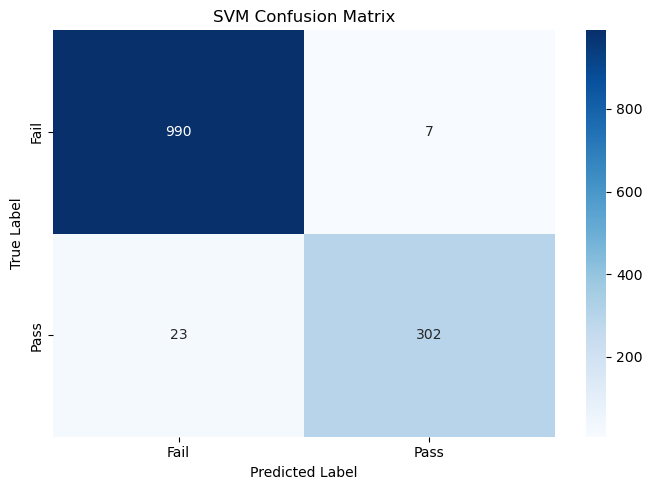

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [13]:
comparison_rows = [
    {"Model": "Logistic Regression", "Accuracy": None, "Precision": None, "Recall": None, "F1-Score": None},
    {"Model": "Decision Tree", "Accuracy": None, "Precision": None, "Recall": None, "F1-Score": None},
    {"Model": "Random Forest", "Accuracy": None, "Precision": None, "Recall": None, "F1-Score": None},
    svm_metrics
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,NaN,NaN,NaN,NaN
1,Decision Tree,NaN,NaN,NaN,NaN
2,Random Forest,NaN,NaN,NaN,NaN
3,SVM,0.977307,0.977308,0.977307,0.977111


In [14]:
print(label_encoder.classes_)



['Fail' 'Pass']
